Reading file: /Users/xylu/Desktop/Data/ahfb_local/LERDH_10_Feb_2026_08_25_52.igp...
Data loaded: 491520 points.
Y Range (mm): Min=-0.2120, Max=0.5330
Generating plot...
DONE. Plot saved to: beam_deviation_simple.png


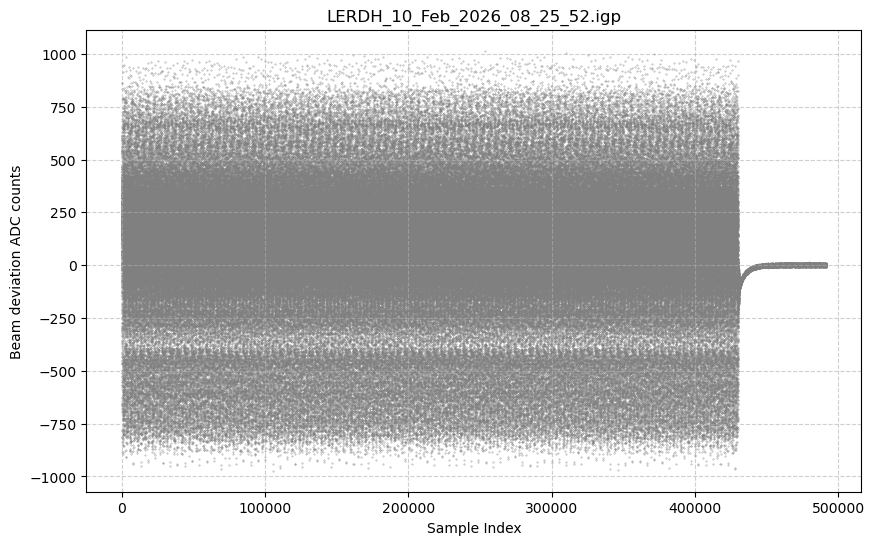

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def read_igp_binary(filename):
    """
    Reads .igp file as 16-bit signed integers (Little Endian).
    """
    try:
        # Read as 16-bit signed integers (no header)
        data = np.fromfile(filename, dtype='<i2')
        return data
        
    except Exception as e:
        print(f"Error reading binary file: {e}")
        return None

def create_plot(filename):
    # 1. Load Data
    print(f"Reading file: {filename}...")
    raw_y = read_igp_binary(filename)
    
    if raw_y is None or len(raw_y) == 0:
        print("ERROR: No data found in file.")
        return

    print(f"Data loaded: {len(raw_y)} points.")

    # 2. Scaling
    # Converting counts to mm (Assumption: 1 count = 1 nm -> 0.000001 mm)
    # y = raw_y * 0.001 
    
    # DEBUG: Print range to ensure values make sense
    print(f"Y Range (mm): Min={np.min(y):.4f}, Max={np.max(y):.4f}")

    # 3. Index Axis
    x = np.arange(len(raw_y))

    # 4. Plotting
    print("Generating plot...")
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # --- Plot ---
    ax.set_title(os.path.basename(filename))
    
    # CRITICAL FIX: rasterized=True prevents OverflowError/Memory crashes for large data
    ax.scatter(x, raw_y, color='grey', marker = "o",alpha=0.8, s=0.1, rasterized=True)
    
    ax.set_ylabel('Beam deviation ADC counts')
    ax.set_xlabel('Sample Index')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # ax.set_xlim(0, 2)
    # ax.set_xticks(np.arange(0, 9, 2))

    plt.subplots_adjust(hspace=0.05)
    
    output_filename = "beam_deviation_simple.png"
    plt.savefig(output_filename, dpi=150, bbox_inches='tight')
    print(f"DONE. Plot saved to: {output_filename}")
    plt.show()

# --- Run ---
# Update this path to your specific file location
file_path = "/Users/xylu/Desktop/Data/ahfb_local/LERDH_10_Feb_2026_08_25_52.igp" 
create_plot(file_path)

Total samples: 491520
Time per sample: 1.965 ns (2 RF buckets)
Total time span: 965.89 µs (0.966 ms)


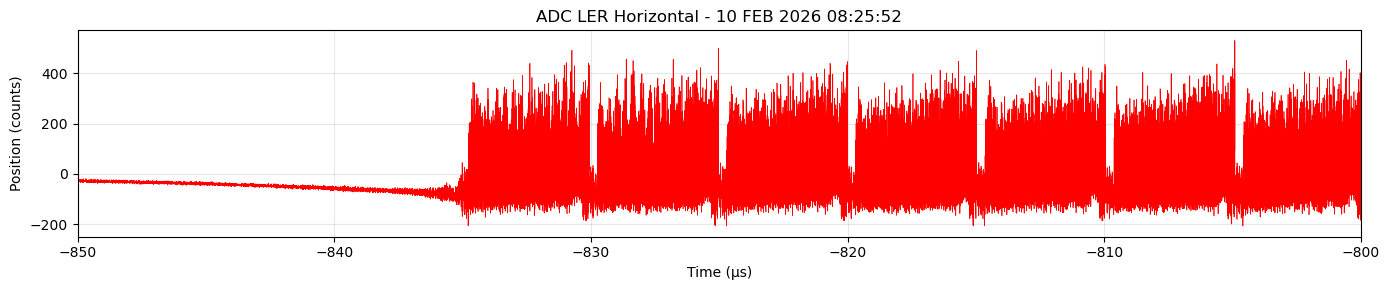

In [70]:
file_path = "/Users/xylu/Desktop/Data/ahfb_local/LERUH_10_Feb_2026_08_25_52.igp"

import numpy as np
import matplotlib.pyplot as plt

# 1. Load Data
# The file is a continuous stream of bunches (16-bit signed integers, no header).
data = np.fromfile(file_path, dtype='<i2')

# 2. Convert to position in mm
# y = data * 0.001

# 3. Time axis calculation
# Two consecutive data points are 2 RF buckets apart
# RF frequency: 508.876 MHz -> 1 RF bucket = 1/508.876e6 seconds
rf_freq = 508.876e6  # Hz
time_per_bucket = 1 / rf_freq  # seconds
time_per_sample = time_per_bucket  # 2 buckets between samples
x = np.arange(len(data)) * time_per_sample * 1e6  # Convert to microseconds
x_flipped_shifted = -x

print(f"Total samples: {len(data)}")
print(f"Time per sample: {time_per_sample*1e9:.3f} ns (2 RF buckets)")
print(f"Total time span: {x[-1]:.2f} µs ({x[-1]/1000:.3f} ms)")

# 4. Plot full dataset
plt.figure(figsize=(14, 3))
plt.plot(x_flipped_shifted, data, color='red', linewidth=0.5)
plt.xlim(-850, -800)
plt.title("ADC LER Horizontal - 10 FEB 2026 08:25:52")
plt.xlabel("Time (µs)")
plt.ylabel("Position (counts)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# DIAGNOSTIC: Determine if file is 16-bit, 24-bit, or 32-bit
file_path = "/Users/xylu/Desktop/Data/ahfb_local/LERUH_10_Feb_2026_08_25_52.igp"

import os
import numpy as np

# Get file size
file_size = os.path.getsize(file_path)
print(f"Total file size: {file_size} bytes")

# Assume 4-byte header (based on your code)
header_size = 4
data_size = file_size - header_size
print(f"Data size (after header): {data_size} bytes")

# Check divisibility
print(f"\n--- Divisibility Check ---")
print(f"Divides evenly by 2 (16-bit): {data_size % 2 == 0}")
print(f"Divides evenly by 3 (24-bit): {data_size % 3 == 0}")
print(f"Divides evenly by 4 (32-bit): {data_size % 4 == 0}")

if data_size % 2 == 0:
    print(f"  → If 16-bit: {data_size // 2} samples")
if data_size % 3 == 0:
    print(f"  → If 24-bit: {data_size // 3} samples")
if data_size % 4 == 0:
    print(f"  → If 32-bit: {data_size // 4} samples")

# Try all interpretations
print(f"\n--- Value Range Comparison ---")

# 16-bit interpretation
data_16bit = np.fromfile(file_path, dtype='<i2')[2:]  # Skip 4-byte header = 2 int16s
print(f"16-bit: min={np.min(data_16bit)}, max={np.max(data_16bit)}, range={np.max(data_16bit)-np.min(data_16bit)}")

# 32-bit interpretation
data_32bit = np.fromfile(file_path, dtype='<i4')[1:]  # Skip 4-byte header = 1 int32
print(f"32-bit: min={np.min(data_32bit)}, max={np.max(data_32bit)}, range={np.max(data_32bit)-np.min(data_32bit)}")

# 24-bit interpretation
with open(file_path, 'rb') as f:
    raw = f.read()
raw_bytes = raw[4:]
n_samples_24 = len(raw_bytes) // 3
if n_samples_24 > 0:
    valid_bytes = raw_bytes[:n_samples_24*3]
    bytes_array = np.frombuffer(valid_bytes, dtype=np.uint8)
    bytes_reshaped = bytes_array.reshape(-1, 3)
    b0 = bytes_reshaped[:, 0].astype(np.int32)
    b1 = bytes_reshaped[:, 1].astype(np.int32)
    b2 = bytes_reshaped[:, 2].astype(np.int32)
    data_24bit = b0 | (b1 << 8) | (b2 << 16)
    data_24bit = np.where(data_24bit & 0x800000, data_24bit - 0x1000000, data_24bit)
    print(f"24-bit: min={np.min(data_24bit)}, max={np.max(data_24bit)}, range={np.max(data_24bit)-np.min(data_24bit)}")

print(f"\n--- Expected Ranges ---")
print(f"16-bit signed: -32,768 to +32,767")
print(f"32-bit signed: -2,147,483,648 to +2,147,483,647")
print(f"24-bit signed: -8,388,608 to +8,388,607")

print(f"\n--- Quick Visual Test ---")
print(f"First 10 values (16-bit): {data_16bit[:10]}")
print(f"First 10 values (32-bit): {data_32bit[:10]}")
if n_samples_24 > 0:
    print(f"First 10 values (24-bit): {data_24bit[:10]}")

print(f"\n--- Reasonableness Check ---")
print(f"16-bit values are in typical ADC range (hundreds): ✓" if abs(np.max(data_16bit)) < 10000 else "16-bit values seem too large")
print(f"32-bit values: {'Unreasonably large' if abs(np.max(data_32bit)) > 100000 else 'Could be valid'}")

Total file size: 983040 bytes
Data size (after header): 983036 bytes

--- Divisibility Check ---
Divides evenly by 2 (16-bit): True
Divides evenly by 3 (24-bit): False
Divides evenly by 4 (32-bit): True
  → If 16-bit: 491518 samples
  → If 32-bit: 245759 samples

--- Value Range Comparison ---
16-bit: min=-212, max=533, range=745
32-bit: min=-12713769, max=32243587, range=44957356
24-bit: min=-8388603, max=8388606, range=16777209

--- Expected Ranges ---
16-bit signed: -32,768 to +32,767
32-bit signed: -2,147,483,648 to +2,147,483,647
24-bit signed: -8,388,608 to +8,388,607

--- Quick Visual Test ---
First 10 values (16-bit): [372  33 295  33 329  43 206 -25 251 -88]
First 10 values (32-bit): [  2163060   2162983   2818377  -1638194  -5766917 -11534082  -6880999
  -7274152  -7864005 -10419920]
First 10 values (24-bit): [ 2163060    75520  4784161    11009 -1638194    64511   -65624   -45056
 -6880999    88319]

--- Reasonableness Check ---
16-bit values are in typical ADC range (hundre

In [32]:
# DIAGNOSTIC: Check if there's actually a header
file_path = "/Users/xylu/Desktop/Data/ahfb_local/LERUH_10_Feb_2026_08_25_52.igp"

import numpy as np

print("--- Checking for Header ---\n")

# Read first 20 bytes as raw hex
with open(file_path, 'rb') as f:
    first_bytes = f.read(20)
    
print("First 20 bytes (hex):")
print(' '.join(f'{b:02x}' for b in first_bytes))

print("\n--- Test with NO header skip ---")
data_no_skip = np.fromfile(file_path, dtype='<i2')
print(f"Total samples: {len(data_no_skip)}")
print(f"First 10 values: {data_no_skip[:10]}")
print(f"Min: {np.min(data_no_skip)}, Max: {np.max(data_no_skip)}")

print("\n--- Test with 4-byte header skip (skip first 2 int16s) ---")
data_skip_4 = np.fromfile(file_path, dtype='<i2')[2:]
print(f"Total samples: {len(data_skip_4)}")
print(f"First 10 values: {data_skip_4[:10]}")
print(f"Min: {np.min(data_skip_4)}, Max: {np.max(data_skip_4)}")

print("\n--- Analysis ---")
print(f"First 2 values (potential header): {data_no_skip[:2]}")
print(f"If header is file size in bytes: {data_no_skip[0]} or {data_no_skip[0] | (data_no_skip[1] << 16)}")
print(f"Actual file size: {len(first_bytes) + len(open(file_path, 'rb').read()) - 20} bytes")

# Check if first values look like typical BPM data or metadata
if abs(data_no_skip[0]) < 1000 and abs(data_no_skip[1]) < 1000:
    print("→ First 2 values look like normal data (hundreds range)")
else:
    print("→ First 2 values might be header/metadata")

--- Checking for Header ---

First 20 bytes (hex):
f1 01 57 00 74 01 21 00 27 01 21 00 49 01 2b 00 ce 00 e7 ff

--- Test with NO header skip ---
Total samples: 491520
First 10 values: [497  87 372  33 295  33 329  43 206 -25]
Min: -212, Max: 533

--- Test with 4-byte header skip (skip first 2 int16s) ---
Total samples: 491518
First 10 values: [372  33 295  33 329  43 206 -25 251 -88]
Min: -212, Max: 533

--- Analysis ---
First 2 values (potential header): [497  87]
If header is file size in bytes: 497 or 5702129
Actual file size: 983040 bytes
→ First 2 values look like normal data (hundreds range)
